In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [3]:
import torch

from src.model import UNet


device = torch.device("mps")

model = UNet().to(device)

model.load_state_dict(
    torch.load(
        "../models/epoch20_best_model.pt",
        map_location=device,
    )
)

model.eval()

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
 

In [4]:
def predict(model, image, device, threshold=0.5):
    model.eval()

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)

        logits = model(image)

        probability = torch.sigmoid(logits)

        prediction = probability >= threshold

    return (
        probability.squeeze().cpu().numpy(),
        prediction.squeeze().cpu().numpy(),
    )

In [8]:
from torch.utils.data import DataLoader
import torch
from src.dataset import OilSpillDataset

val_dataset = OilSpillDataset(
    image_dir="../data/images/val",
    mask_dir="../data/masks/val",
)

print("val:", len(val_dataset))

val: 1615


In [10]:
import matplotlib.pyplot as plt
import numpy as np


rng = np.random.default_rng(42)

indices = rng.choice(
    len(val_dataset),
    size=12,
    replace=False,
)

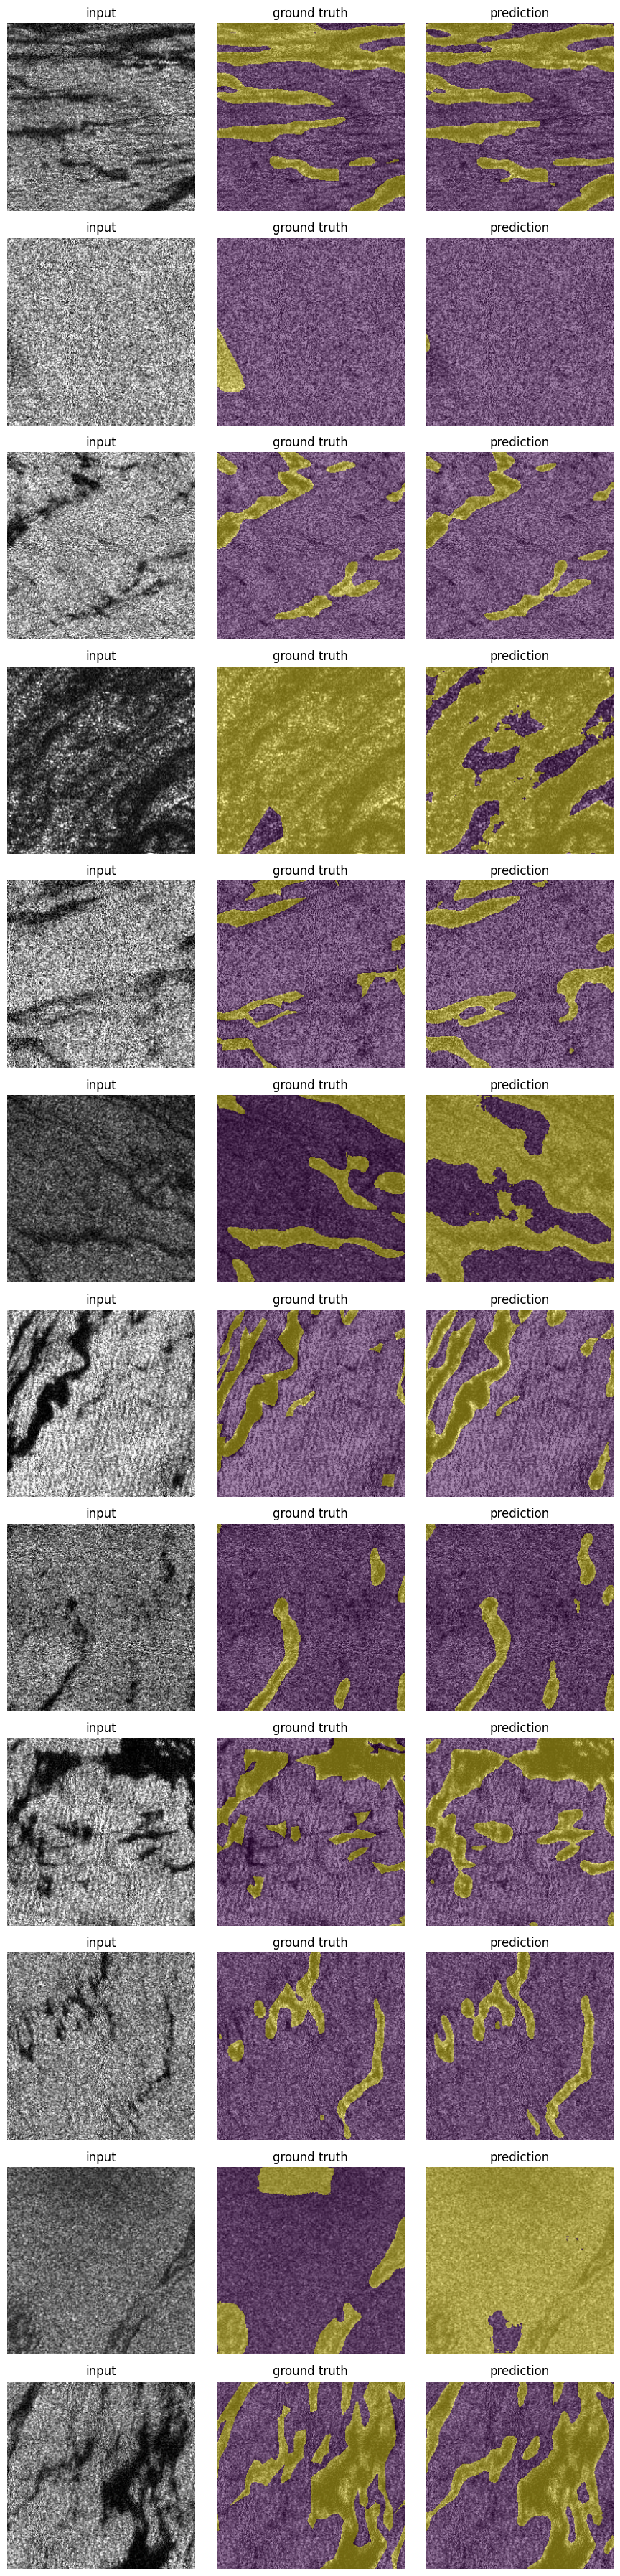

In [11]:
fig, axes = plt.subplots(
    12,
    3,
    figsize=(9, 36),
)


for row, idx in enumerate(indices):
    image, mask = val_dataset[idx]

    probability, prediction = predict(
        model,
        image,
        device,
    )

    image = image.squeeze().numpy()
    mask = mask.squeeze().numpy()

    # image
    axes[row, 0].imshow(
        image,
        cmap="gray",
    )
    axes[row, 0].set_title("input")

    # ground truth
    axes[row, 1].imshow(
        image,
        cmap="gray",
    )
    axes[row, 1].imshow(
        mask,
        alpha=0.45,
    )
    axes[row, 1].set_title("ground truth")

    # prediction
    axes[row, 2].imshow(
        image,
        cmap="gray",
    )
    axes[row, 2].imshow(
        prediction,
        alpha=0.45,
    )
    axes[row, 2].set_title("prediction")

    for col in range(3):
        axes[row, col].axis("off")


plt.tight_layout()
plt.show()

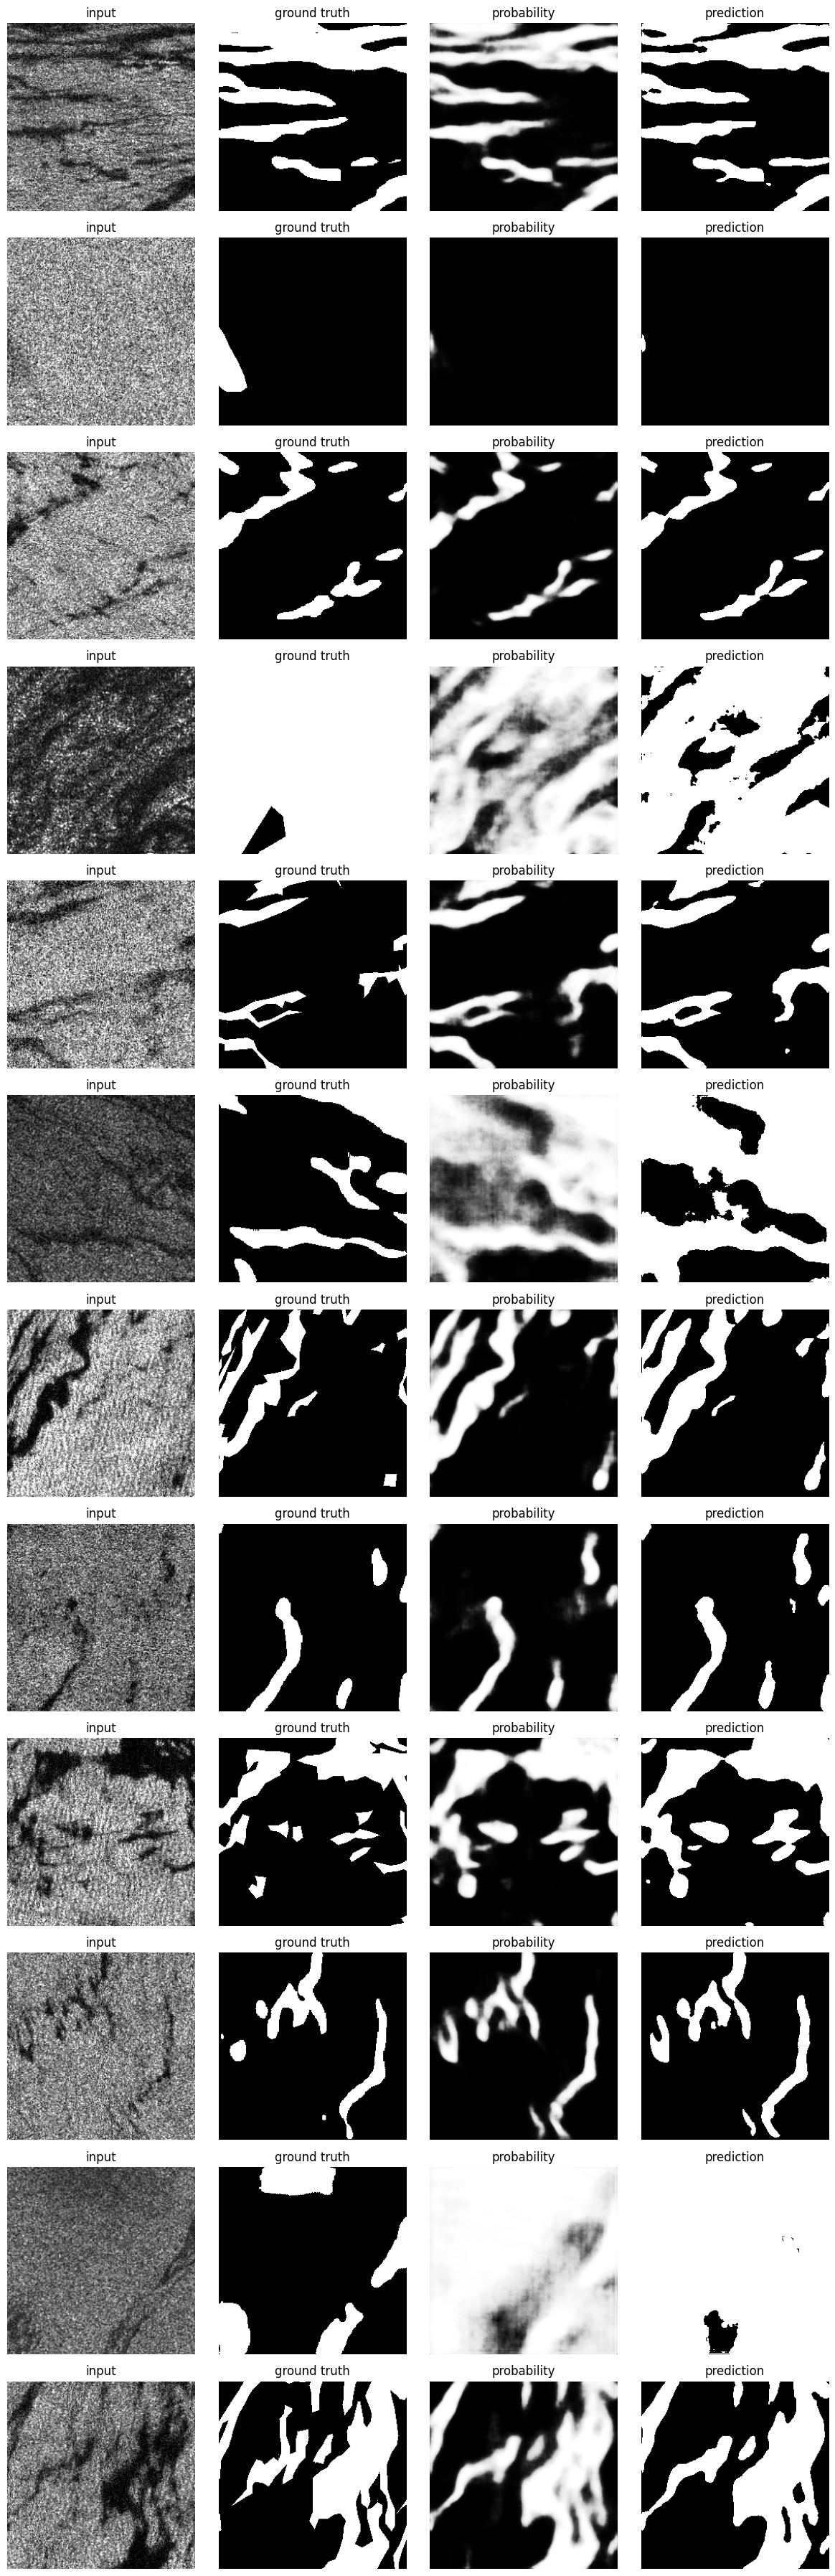

In [12]:
fig, axes = plt.subplots(
    12,
    4,
    figsize=(12, 36),
)

for row, idx in enumerate(indices):
    image, mask = val_dataset[idx]

    probability, prediction = predict(
        model,
        image,
        device,
    )

    image = image.squeeze().numpy()
    mask = mask.squeeze().numpy()

    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_title("input")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("ground truth")

    axes[row, 2].imshow(probability, cmap="gray")
    axes[row, 2].set_title("probability")

    axes[row, 3].imshow(prediction, cmap="gray")
    axes[row, 3].set_title("prediction")

    for col in range(4):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

Hey this stuff works! For the most part at least, some predictions are way off, where the entire image is either maximally oil spill OR maximally no spill.

This follows, considering our training images have a 25-ish% mean and 17-ish% median spill percentage. 

To illustrate this smokeshow:

In [13]:
empty_indices = []

for idx in range(len(val_dataset)):
    _, mask = val_dataset[idx]

    if mask.sum() == 0:
        empty_indices.append(idx)

print("empty validation masks:", len(empty_indices))
print(empty_indices[:20])

empty validation masks: 76
[21, 35, 47, 75, 84, 120, 122, 134, 168, 170, 175, 185, 192, 199, 210, 213, 238, 239, 283, 288]


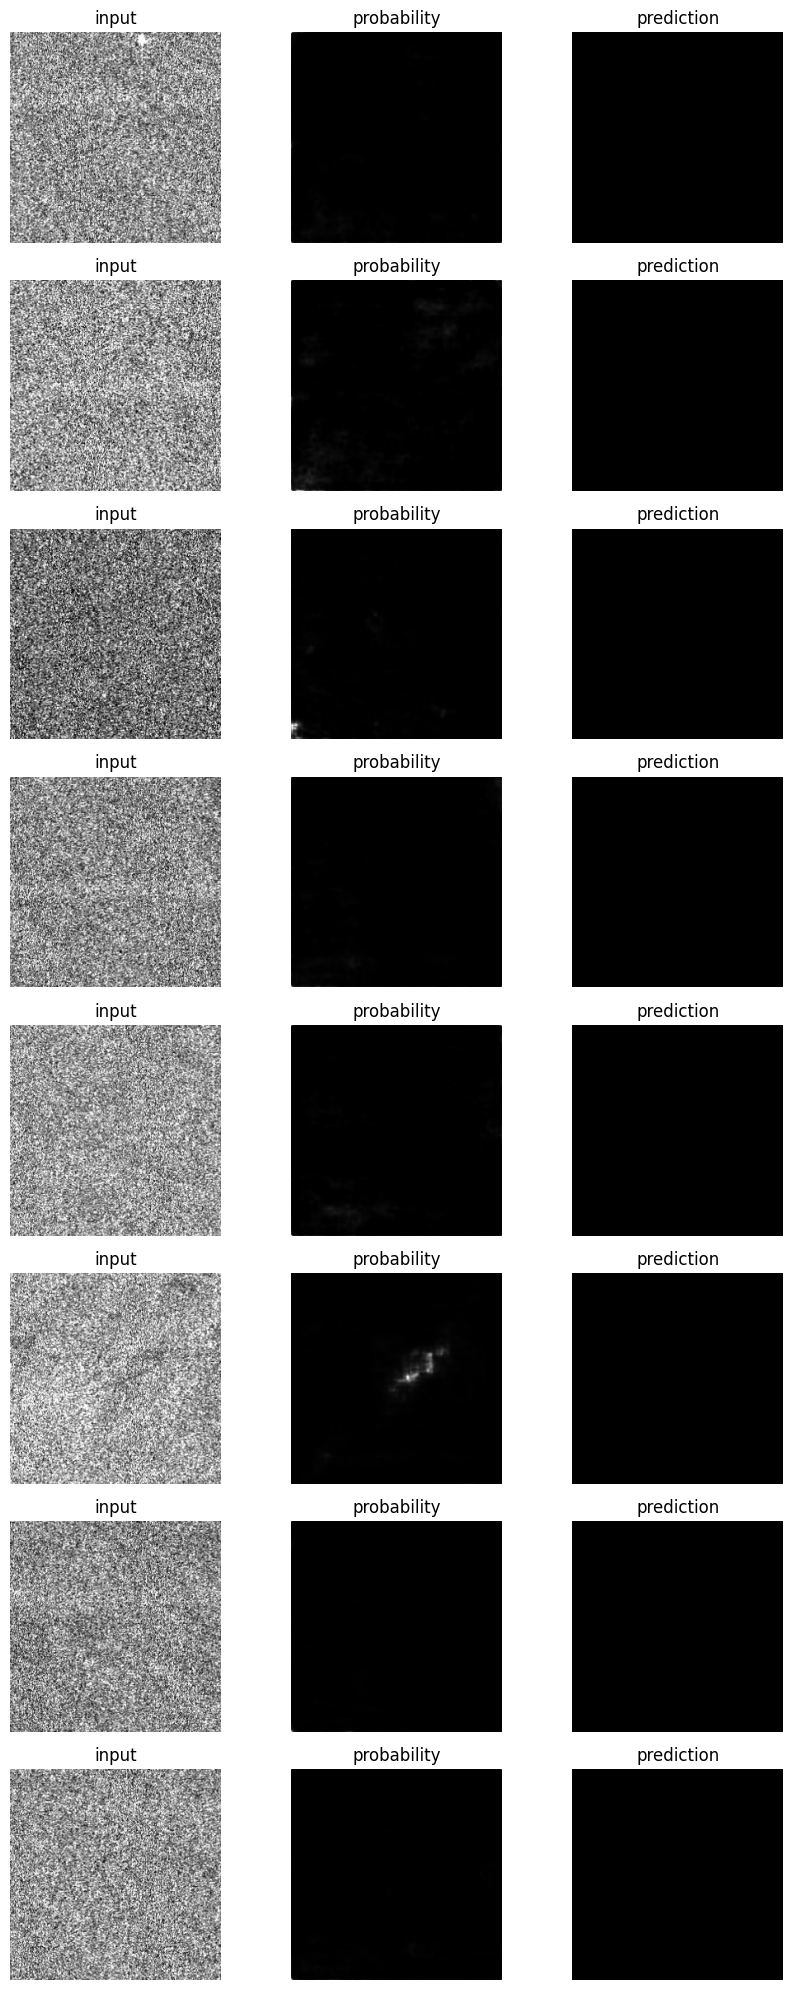

In [14]:
fig, axes = plt.subplots(
    min(len(empty_indices), 8),
    3,
    figsize=(9, 20),
)

for row, idx in enumerate(empty_indices[:8]):
    image, mask = val_dataset[idx]

    probability, prediction = predict(
        model,
        image,
        device,
    )

    image = image.squeeze().numpy()

    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_title("input")

    axes[row, 1].imshow(probability, cmap="gray")
    axes[row, 1].set_title("probability")

    axes[row, 2].imshow(prediction, cmap="gray")
    axes[row, 2].set_title("prediction")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

Hm, not too bad honestly, pretty good.

Let's compare Sentinel vs PALSAR predictions, they had a roughly 50-50 split with ~3000 images each in the training dataset.

In [15]:
from collections import defaultdict


sensor_metrics = defaultdict(
    lambda: {
        "tp": 0,
        "fp": 0,
        "fn": 0,
    }
)


for idx in range(len(val_dataset)):
    image, mask = val_dataset[idx]

    probability, prediction = predict(
        model,
        image,
        device,
    )

    image_name = val_dataset.image_paths[idx].name

    sensor = image_name.split("_")[0]

    prediction = prediction.astype(bool)
    mask = mask.squeeze().numpy().astype(bool)

    sensor_metrics[sensor]["tp"] += np.logical_and(
        prediction,
        mask,
    ).sum()

    sensor_metrics[sensor]["fp"] += np.logical_and(
        prediction,
        ~mask,
    ).sum()

    sensor_metrics[sensor]["fn"] += np.logical_and(
        ~prediction,
        mask,
    ).sum()


for sensor, values in sensor_metrics.items():
    tp = values["tp"]
    fp = values["fp"]
    fn = values["fn"]

    dice = (
        2 * tp
        / (2 * tp + fp + fn + 1e-7)
    )

    iou = (
        tp
        / (tp + fp + fn + 1e-7)
    )

    precision = (
        tp
        / (tp + fp + 1e-7)
    )

    recall = (
        tp
        / (tp + fn + 1e-7)
    )

    print(sensor.upper())

    print(f"  Dice:      {dice:.4f}")
    print(f"  IoU:       {iou:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")

PALSAR
  Dice:      0.8367
  IoU:       0.7192
  Precision: 0.8456
  Recall:    0.8279
SENTINEL
  Dice:      0.8551
  IoU:       0.7469
  Precision: 0.8236
  Recall:    0.8892


Hey! Not too bad!